# Q6 project — extra metrics for the AI / memory / inference book

Пояснення метрик звичайною мовою, таблиця CapEx і карта «платник → підрядник»: [Q6-METRICS.md](Q6-METRICS.md)

Список компаній (категорії A / B / C): [../q5-ai-infra-capstone/INFRA-CAPSTONE.md](../q5-ai-infra-capstone/INFRA-CAPSTONE.md)

Standalone notebook (does **not** depend on `homework1.ipynb` or the Q5 notebook).

**Job:** pull the series that the Q5 capstone actually needs, say *why*, and show the Python path.

| Metric | Source | Why |
|---|---|---|
| `^SOX` PHLX Semiconductor | yfinance | Cycle benchmark vs single-stock beta |
| `IPB53122S` semi industrial production | FRED | Real output, not just price |
| `VIXCLS`, `T10Y2Y`, `FEDFUNDS` | FRED | Vol / curve / policy regime |
| Earnings surprise + 2-day return | yfinance `get_earnings_dates` | Event features (same recipe as HW1 Q4) |
| Wikipedia GICS + Date added | Wikipedia | Sleeve dummies, index-inclusion flow |
| Yahoo `info` snapshot | yfinance | Forward PE / margin / mkt-cap gates |



## Setup


In [1]:
%pip install yfinance pandas pandas-datareader lxml beautifulsoup4 requests truststore curl_cffi matplotlib

import truststore
truststore.inject_into_ssl()

import warnings
warnings.filterwarnings("ignore")

import requests
import pandas as pd
import numpy as np
import yfinance as yf
import pandas_datareader as pdr
from curl_cffi import requests as curl_requests
from io import StringIO
import matplotlib.pyplot as plt

# FRED: pandas_datareader opens its own Session — inject a post-truststore session.
_orig = pdr.DataReader

def DataReader(name, data_source, start=None, end=None, **kwargs):
    if data_source == "fred" and "session" not in kwargs:
        kwargs["session"] = requests.Session()
    return _orig(name, data_source, start=start, end=end, **kwargs)

pdr.DataReader = DataReader

yf_session = curl_requests.Session(impersonate="chrome", verify=False)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("setup ok")



setup ok


## 1. Cycle: `^SOX` vs NVDA / MU / SK Hynix


corr of daily returns
            SOX   NVDA     MU  SK Hynix   AVGO    SPX
SOX      1.0000 0.7200 0.7800    0.2000 0.7500 0.7800
NVDA     0.7200 1.0000 0.4900    0.1700 0.5900 0.6500
MU       0.7800 0.4900 1.0000    0.2900 0.5400 0.5500
SK Hynix 0.2000 0.1700 0.2900    1.0000 0.1200 0.1000
AVGO     0.7500 0.5900 0.5400    0.1200 1.0000 0.6200
SPX      0.7800 0.6500 0.5500    0.1000 0.6200 1.0000

YTD 2026
MU         2.0651
SK Hynix   1.5554
SOX        0.5935
NVDA       0.1370
SPX        0.1190
AVGO       0.0599
dtype: float64


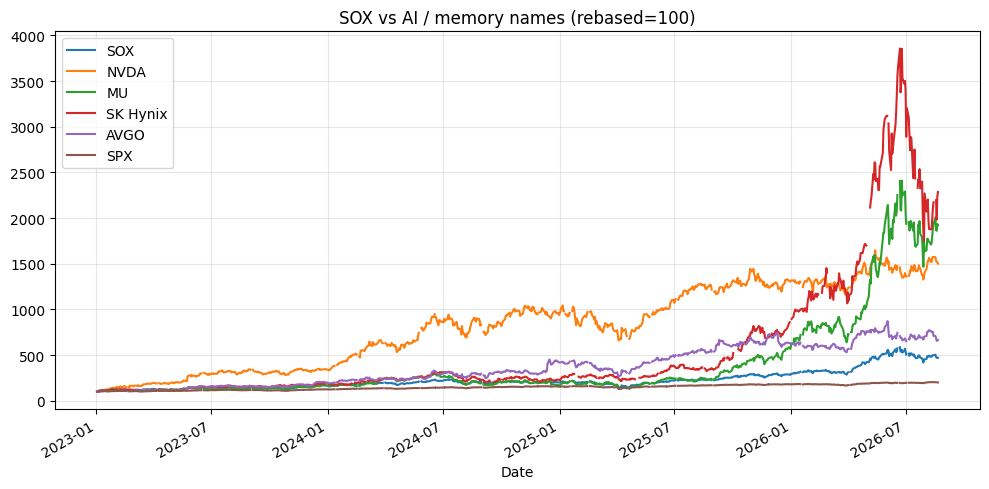

In [2]:
cycle_tickers = ["^SOX", "NVDA", "MU", "000660.KS", "AVGO", "^GSPC"]
raw = yf.download(
    cycle_tickers,
    start="2023-01-01",
    end="2026-08-22",
    auto_adjust=False,
    group_by="ticker",
    threads=True,
    session=yf_session,
    progress=False,
)

def close_of(t):
    s = raw[t]["Close"].dropna()
    if getattr(s.index, "tz", None) is not None:
        s.index = s.index.tz_localize(None)
    return s.loc[: pd.Timestamp("2026-08-21")]

cycle = pd.DataFrame({t: close_of(t) for t in cycle_tickers}).dropna(how="all")
cycle = cycle.rename(columns={"000660.KS": "SK Hynix", "^SOX": "SOX", "^GSPC": "SPX"})
rebased = cycle / cycle.apply(lambda s: s.dropna().iloc[0]) * 100
ax = rebased.plot(figsize=(10, 5), title="SOX vs AI / memory names (rebased=100)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("corr of daily returns")
print(cycle.pct_change().corr().round(2))
print("\nYTD 2026")
ytd = cycle.loc["2026-01-01":]
print((ytd.iloc[-1] / ytd.apply(lambda s: s.dropna().iloc[0]) - 1).sort_values(ascending=False))



## 2. FRED regime + semiconductor industrial production


               VIX  10y-2y spread  Fed funds  Semi industrial production
DATE                                                                    
2026-08-19 14.8900         0.4600        NaN                         NaN
2026-08-20 16.0100         0.5000        NaN                         NaN
2026-08-21 15.1300         0.5000        NaN                         NaN
2026-08-24 15.8500         0.4600        NaN                         NaN
2026-08-25 15.4500         0.4700        NaN                         NaN
2026-08-26 15.2100         0.4700        NaN                         NaN
2026-08-27 14.5100         0.4700        NaN                         NaN
2026-08-28     NaN         0.3900        NaN                         NaN

latest
VIX                             NaN
10y-2y spread                0.3900
Fed funds                       NaN
Semi industrial production      NaN
Name: 2026-08-28 00:00:00, dtype: float64
WHY
  VIX            — change size when vol spikes (AI names are high-beta).

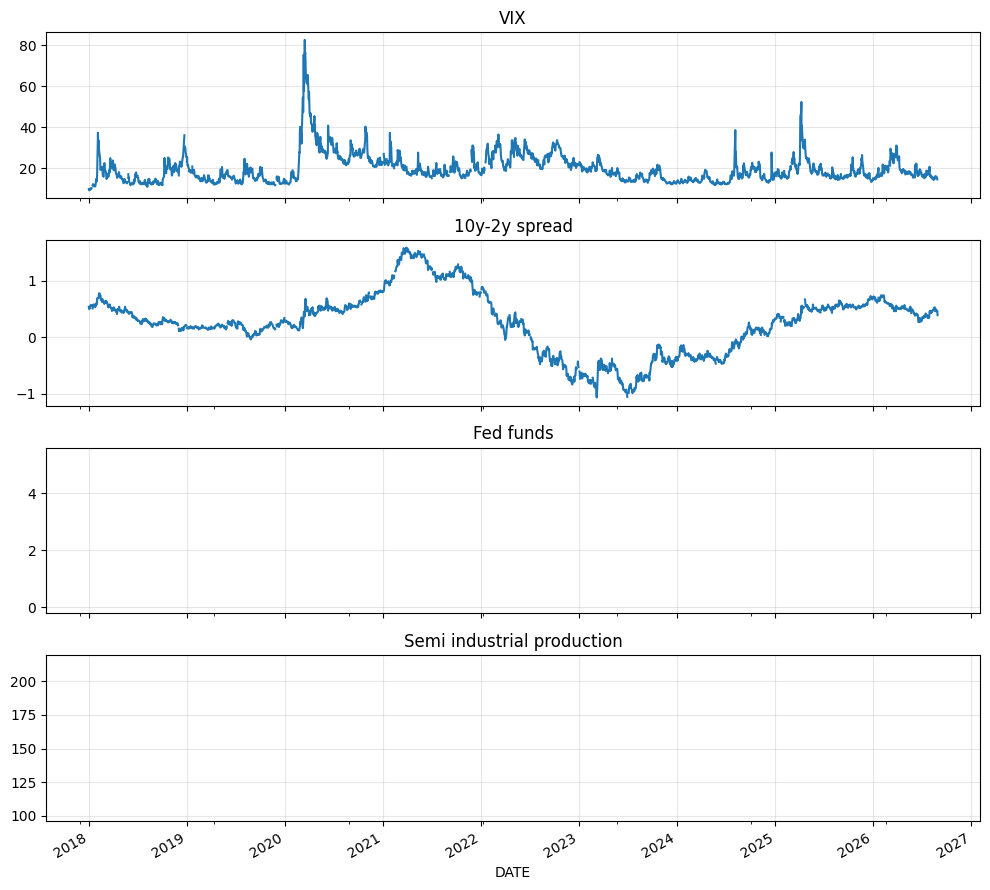

In [3]:
fred_ids = {
    "VIXCLS": "VIX",
    "T10Y2Y": "10y-2y spread",
    "FEDFUNDS": "Fed funds",
    "IPB53122S": "Semi industrial production",
}
fred = pd.concat(
    {lab: pdr.DataReader(sid, "fred", start="2018-01-01")[sid] for sid, lab in fred_ids.items()},
    axis=1,
)
print(fred.tail(8))
print("\nlatest")
print(fred.dropna(how="all").iloc[-1])

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
for ax, col in zip(axes, fred.columns):
    fred[col].plot(ax=ax, title=col)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('''WHY
  VIX            — change size when vol spikes (AI names are high-beta).
  T10Y2Y         — inverted curve historically precedes risk-off in cyclicals/semis.
  FEDFUNDS       — discount-rate regime for long-duration AI winners.
  IPB53122S      — real chip output. If prices run and IP stalls, squeeze risk.
''')



## 3. Earnings surprise + 2-day return (NVDA, MU, AVGO, AMD)


In [4]:
def two_day_after_earnings(ticker: str) -> pd.DataFrame:
    obj = yf.Ticker(ticker, session=yf_session)
    earn = obj.get_earnings_dates().copy()
    earn = earn.dropna(subset=["Reported EPS", "Surprise(%)"])
    px = obj.history(period="max", auto_adjust=False)
    if getattr(px.index, "tz", None) is not None:
        px.index = px.index.tz_localize(None)
    closes = px["Close"]
    ret_2d = closes.shift(-1) / closes.shift(1) - 1
    earn.index = pd.to_datetime(earn.index)
    if getattr(earn.index, "tz", None) is not None:
        earn.index = earn.index.tz_localize(None)
    earn.index = earn.index.normalize()
    earn = earn[~earn.index.duplicated(keep="first")]
    earn["ret_2d"] = ret_2d.reindex(earn.index)
    missing = earn["ret_2d"].isna()
    for dt in earn.index[missing]:
        later = closes.index[closes.index >= dt]
        if len(later):
            earn.loc[dt, "ret_2d"] = ret_2d.get(later[0], np.nan)
    earn["ticker"] = ticker
    return earn


event_names = ["NVDA", "MU", "AVGO", "AMD"]
events = pd.concat([two_day_after_earnings(t) for t in event_names])
pos = events[events["Surprise(%)"] > 0]

print("median 2-day return after +surprise")
print(pos.groupby("ticker")["ret_2d"].median())
print("\ncorr(ret_2d, Surprise%) by name")
print(
    events.groupby("ticker").apply(
        lambda d: d[["ret_2d", "Surprise(%)"]].dropna().corr().iloc[0, 1]
    )
)
print("\nlast 3 prints per name")
print(
    events.sort_index()
    .groupby("ticker")
    .tail(3)[["ticker", "Reported EPS", "Surprise(%)", "ret_2d"]]
)



median 2-day return after +surprise
ticker
AMD    -0.0053
AVGO    0.0071
MU     -0.0177
NVDA   -0.0005
Name: ret_2d, dtype: float64

corr(ret_2d, Surprise%) by name
ticker
AMD     0.1069
AVGO   -0.2100
MU      0.3150
NVDA    0.3071
dtype: float64

last 3 prints per name
              ticker  Reported EPS  Surprise(%)  ret_2d
Earnings Date                                          
2025-12-11      AVGO        1.9500       4.3800 -0.1284
2025-12-17        MU        4.7800      20.5800  0.0690
2026-02-03       AMD        1.5300      15.9800 -0.1871
2026-02-25      NVDA        1.6200       5.3200 -0.0413
2026-03-04      AVGO        2.0500       1.3200  0.0603
2026-03-18        MU       12.2000      33.2100 -0.0377
2026-05-05       AMD        1.3700       5.8200  0.2338
2026-05-20      NVDA        1.8700       5.5400 -0.0050
2026-06-03      AVGO        2.4400       1.7400 -0.1301
2026-06-24        MU       25.1100      21.3900  0.1538
2026-08-04       AMD        1.6600       3.2100 -0.0053
2

## 4. Wikipedia GICS / Date added (index-inclusion feature)


In [5]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    )
}
html = requests.get(url, headers=headers)
html.raise_for_status()
spx = pd.read_html(StringIO(html.text))[0]
spx["Date added"] = pd.to_datetime(spx["Date added"], errors="coerce")

want = [
    "NVDA", "AVGO", "AMD", "AMAT", "MU", "WDC", "ANET",
    "GOOGL", "MSFT", "AMZN", "META", "SMCI",
]
wiki = spx[spx["Symbol"].isin(want)][
    ["Symbol", "Security", "GICS Sector", "GICS Sub-Industry", "Date added"]
].sort_values("Symbol")
print(wiki.to_string(index=False))
print("\nWHY: GICS dummies + years-in-index. New members get forced buying from index funds.")
print("Not in S&P 500 (still in the book): TSM, ASML, ARM, ALAB, CRDO, SK Hynix, Samsung, SNDK, VRT, MRVL (check live).")
print("Missing from this scrape:", sorted(set(want) - set(wiki["Symbol"])))



Symbol                Security            GICS Sector                          GICS Sub-Industry Date added
  AMAT       Applied Materials Information Technology        Semiconductor Materials & Equipment 1995-03-16
   AMD  Advanced Micro Devices Information Technology                             Semiconductors 2017-03-20
  AMZN                  Amazon Consumer Discretionary                           Broadline Retail 2005-11-18
  ANET         Arista Networks Information Technology                   Communications Equipment 2018-08-28
  AVGO                Broadcom Information Technology                             Semiconductors 2014-05-08
 GOOGL Alphabet Inc. (Class A) Communication Services               Interactive Media & Services 2006-04-03
  META          Meta Platforms Communication Services               Interactive Media & Services 2013-12-23
  MSFT               Microsoft Information Technology                           Systems Software 1994-06-01
    MU       Micron Technolo

## 5. Yahoo `info` snapshot — valuation / quality gates


In [6]:
snap_tickers = [
    "NVDA", "AVGO", "AMD", "TSM", "MU", "000660.KS", "VRT",
    "MRVL", "ALAB", "CRDO", "GOOGL", "SMCI",
]
rows = []
for t in snap_tickers:
    info = yf.Ticker(t, session=yf_session).info or {}
    rows.append(
        {
            "ticker": t,
            "name": info.get("shortName"),
            "mkt_cap_b": (info.get("marketCap") or np.nan) / 1e9,
            "fwd_pe": info.get("forwardPE"),
            "trail_pe": info.get("trailingPE"),
            "profit_margin": info.get("profitMargins"),
            "beta": info.get("beta"),
        }
    )
snap = pd.DataFrame(rows).set_index("ticker")
print(snap)
print('''\nWHY
  forward PE / margin / beta are hard gates: skip names with no earnings
  or extreme beta unless the sleeve overlay says "bottleneck".
  Pull: yf.Ticker(t).info  (same SSL session as prices).
''')



                                      name      mkt_cap_b  ...  profit_margin   beta
ticker                                                     ...                      
NVDA                    NVIDIA Corporation     5,253.1796  ...         0.6366 2.2150
AVGO                         Broadcom Inc.     1,754.5480  ...         0.3885 1.4730
AMD           Advanced Micro Devices, Inc.       760.0477  ...         0.1558 2.4890
TSM        Taiwan Semiconductor Manufactur     2,165.4565  ...         0.4992 1.2580
MU                 Micron Technology, Inc.     1,053.5656  ...         0.5591 2.2130
000660.KS                         SK hynix 1,169,840.9119  ...         0.8562 2.3950
VRT                   Vertiv Holdings, LLC        98.9728  ...         0.1509 2.0770
MRVL              Marvell Technology, Inc.       194.6774  ...         0.2793 2.2460
ALAB                     Astera Labs, Inc.        50.2187  ...         0.3074 3.8430
CRDO       Credo Technology Group Holding         43.7418  ...   

## Q6 write-up (form answer)


In [7]:
print('''Q6 ANSWER
For the AI-infra / memory / inference book I add:

1. ^SOX + FRED IPB53122S — semiconductor cycle vs real chip output.
2. FRED VIXCLS, T10Y2Y, FEDFUNDS — vol, curve, policy regime for position size.
3. get_earnings_dates() 2-day returns for NVDA/MU/AVGO/AMD — event features.
4. Wikipedia S&P 500 GICS + Date added — sleeve / inclusion dummies.
5. Yahoo info (fwd PE, margin, mkt cap) — valuation/quality gates.

How to pull
  import pandas_datareader as pdr
  vix = pdr.DataReader("VIXCLS", "fred", start="2018-01-01")
  ip  = pdr.DataReader("IPB53122S", "fred", start="2018-01-01")
  sox = yf.Ticker("^SOX").history(start="2023-01-01")
  earn = yf.Ticker("MU").get_earnings_dates()
  # Wikipedia: requests.get + pd.read_html (User-Agent required)
''')



Q6 ANSWER
For the AI-infra / memory / inference book I add:

1. ^SOX + FRED IPB53122S — semiconductor cycle vs real chip output.
2. FRED VIXCLS, T10Y2Y, FEDFUNDS — vol, curve, policy regime for position size.
3. get_earnings_dates() 2-day returns for NVDA/MU/AVGO/AMD — event features.
4. Wikipedia S&P 500 GICS + Date added — sleeve / inclusion dummies.
5. Yahoo info (fwd PE, margin, mkt cap) — valuation/quality gates.

How to pull
  import pandas_datareader as pdr
  vix = pdr.DataReader("VIXCLS", "fred", start="2018-01-01")
  ip  = pdr.DataReader("IPB53122S", "fred", start="2018-01-01")
  sox = yf.Ticker("^SOX").history(start="2023-01-01")
  earn = yf.Ticker("MU").get_earnings_dates()
  # Wikipedia: requests.get + pd.read_html (User-Agent required)

